# Extract Sign Synthetic

New format of the PINN takes `data_edge`, `data_sign`, and `data_phys` as an input. 
This program creates these data for synthetic examples based on MRC file as well as pre-calculated phase field. 

In [2]:
import sys
sys.path.append('../src')

import absl.logging
absl.logging.set_verbosity(absl.logging.ERROR)

import os
import numpy as np
import matplotlib.pyplot as plt
import jax

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

In [13]:
## To reload

import importlib
# import pinn.cryoet_io as cryoet_io
# import pinn.plot as plot
# import pinn.utils as util
# import data_generation.mesh_to_cryoet as mesh_to_cryoet
import data_generation.preprocess as preprocess

# importlib.reload(cryoet_io)
# importlib.reload(plot)
# importlib.reload(util)
# importlib.reload(mesh_to_cryoet)
importlib.reload(preprocess)

<module 'data_generation.preprocess' from '/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/notebooks/../src/data_generation/preprocess.py'>

### Parameters

In [50]:
shape = "bud_04"
additive = 0.0
missing  = 0.0

str_add = f"{additive:.2f}".replace('.', '')
str_miss = f"{missing:.1f}".replace('.', '')

### Extract Edges
- Input: MRC data (`cryoET_data`)
- Output: `data_edge`

edge:  336
bulk:  819


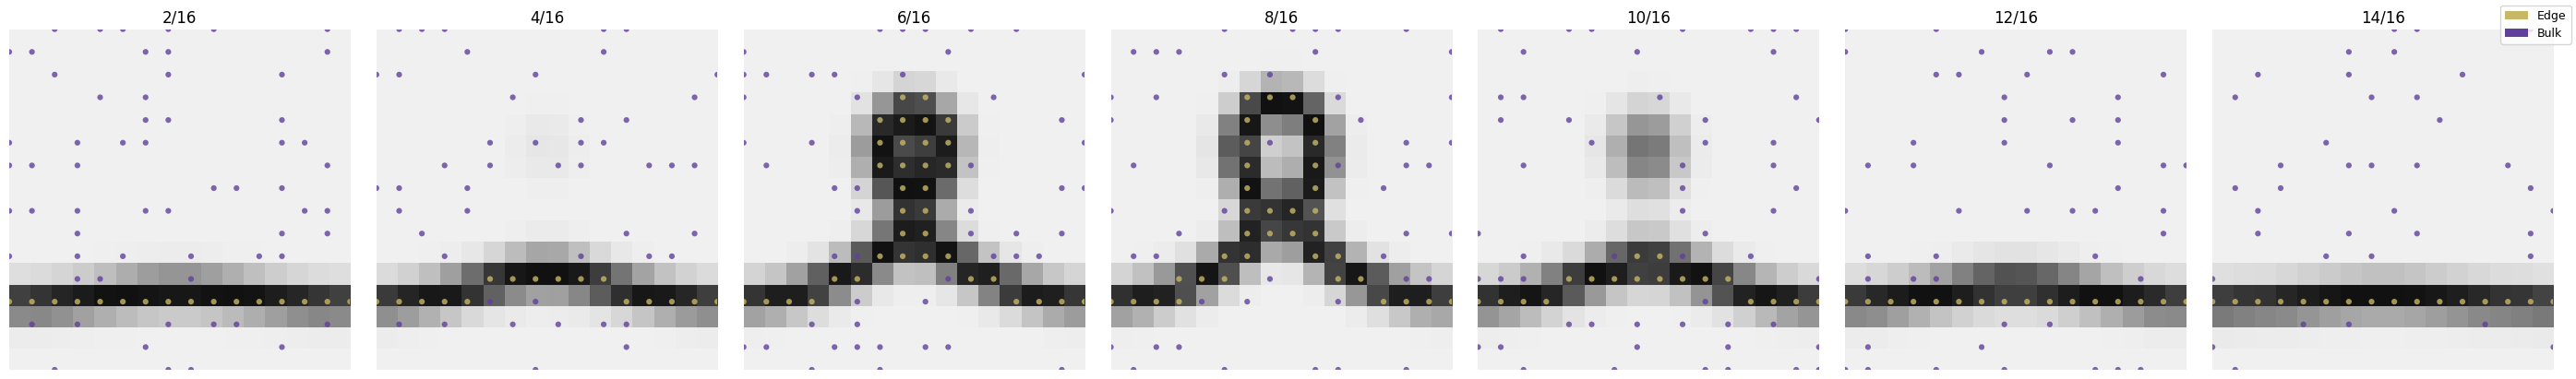

In [54]:
from data_generation.preprocess import downsample_binary_mask_to_fraction, build_data_edge_from_masks, overlay_points_on_cryoet
from pinn.cryoet_io import load_mrc_data
from pinn.utils import save_pts_data

GRID_SIZE = 16

edge_max = 1.0
edge_min = 0.4
target_edge = 1.0
target_bulk = 0.2


## ===== LOAD MRC DATA ========
mrc_file_path = f"../data/synthetic/mrc/{shape}_a{str_add}_m{str_miss}.mrc"
cryoET_data = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE, normalize_mrc=True)

## ===== CALCULATE EDGE AND BULK ========
edge    = (cryoET_data >= edge_min) & (cryoET_data <= edge_max)
bulk    = (~edge)

edge = np.asarray(edge)
bulk = np.asarray(bulk)

edge    = downsample_binary_mask_to_fraction(edge, target_frac=target_edge, seed=0)
bulk    = downsample_binary_mask_to_fraction(bulk, target_frac=target_bulk, seed=0)

edge = edge.astype(np.float32)
bulk = bulk.astype(np.float32)

data_edge = build_data_edge_from_masks(
    edge=edge,
    bulk=bulk,
    volume_shape=cryoET_data.shape,
)

## ===== STORE META DATA ========
meta_edge ={
    "type": "edge",
    "label_meaning": {1: "edge", 0: "bulk"},
    "GRID_SIZE": GRID_SIZE,
    "edge_min": edge_min,
    "edge_max": edge_max,
    "target_edge": target_edge,
    "target_bulk": target_bulk,
    "mrc_path": mrc_file_path,
}

print("edge: ",    (data_edge["label"] == 1).sum())
print("bulk: ",    (data_edge["label"] == 0).sum())

## ===== VISUALIZE DATA ========
slices = list(range(int(GRID_SIZE/8), GRID_SIZE, int(GRID_SIZE/8)))
edge = data_edge["points"][data_edge["label"] == 1][:, [2, 0, 1]]
bulk = data_edge["points"][data_edge["label"] == 0][:, [2, 0, 1]]
overlays = [
    {"data": edge, "label": "Edge", "cmap": "cividis"},
    {"data": bulk, "label": "Bulk", "cmap": "Purples"},
]
overlay_points_on_cryoet(cryoet=cryoET_data, overlays=overlays, axis='z', slice_indices=slices, alpha=0.8)


## ===== SAVE DATA ========
save_data_dir = f"../data/synthetic/pts"
# save_pts_data(data_edge, f"{save_data_dir}/edge/e_{shape}_a{str_add}_m{str_miss}_g{GRID_SIZE}.npz", meta_edge)

### Extract Signs and Collocation Points

- Input: pre-calculated phase field
- Output: `data_sign` and `data_phys`

/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/biconcave/data_0321/ref/checkpoint_10000
positive:  392
nevative:  19608
physics:  40000


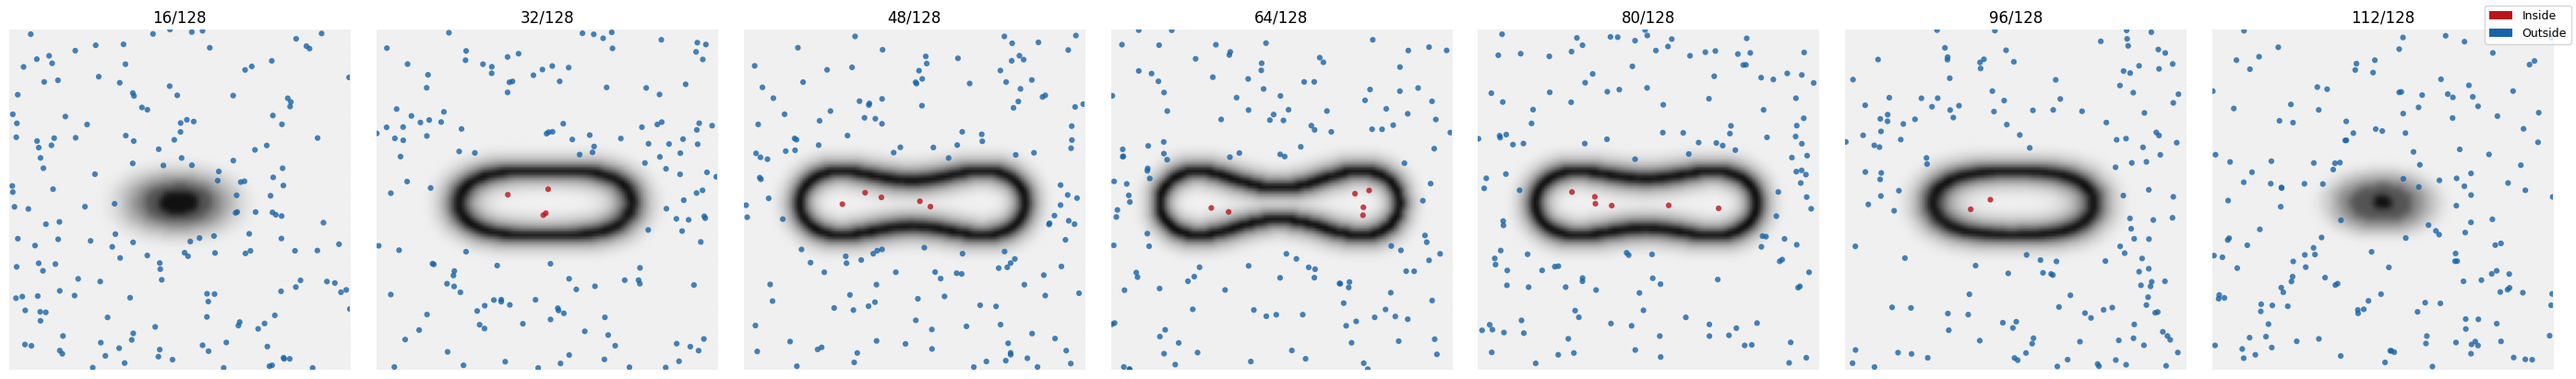

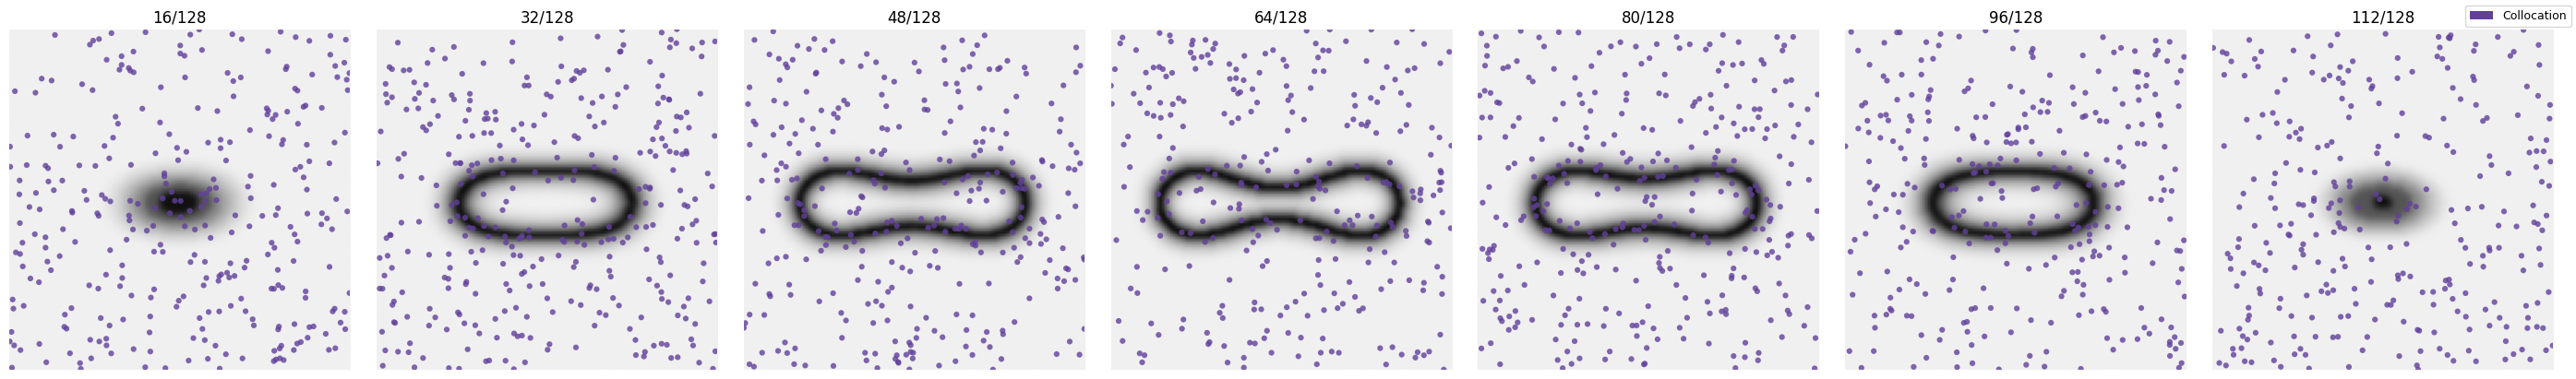

In [52]:
from pinn.utils import sample_sign_points, sample_collocation_points, sample_sign_points_marching_cubes
from flax.training import checkpoints

shape = "biconcave"
num_sign = 20000
num_collocation = 40000
seed = 1
key = jax.random.PRNGKey(seed)
thre_sign = 0.9
sampling_phys = "intensity"
beta_colloc = 1
GRID_SIZE = 128

## ===== LOAD MRC DATA ========
mrc_file_path = f"../data/synthetic/mrc/{shape}_a000_m00.mrc"
cryoET_data = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE, normalize_mrc=True)

# ## ===== LOAD PHASE FIELD ========
data_type = "data_0321"
step = 10000
checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/{data_type}/ref")
checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
checkpoint_data = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)
print(checkpoint_path)

## ===== SIGN SAMPLING ========
data_sign = sample_sign_points(checkpoint=checkpoint_data, threshold=thre_sign, n_sample=num_sign)

# ## ===== COLLOCATION POINTS SAMPLING ========
## (A) Uniform sampling
if sampling_phys == "uniform":
    x_train = (jax.random.uniform(key, (num_collocation, 3), minval=-1, maxval=1))
    data_phys = {"points": x_train}

## (B) Intensity-based sampling
if sampling_phys == "intensity":
    data_phys = sample_collocation_points(key, checkpoint_data, num_collocation, beta=beta_colloc)

# ## ===== STORE META DATA ========
meta_sign ={
    "type": "sign",
    "label_meaning": {1: "postive", -1: "negative"},
    "n_sample": num_sign,
    "threshold": thre_sign,
    "phi_fn": checkpoint_path,
}
meta_phys = {
    "type": "phys",
    "n_sample": num_collocation,
    "seed": seed,
    "sampling": sampling_phys,
    "phi_fn": checkpoint_path,
}

print("positive: ", (data_sign["label"] ==  1).sum())
print("nevative: ", (data_sign["label"] == -1).sum())
print("physics: ", data_phys["points"].shape[0])

## ===== VISUALIZE DATA ========
slices = list(range(int(GRID_SIZE/8), GRID_SIZE, int(GRID_SIZE/8)))
inside  = data_sign["points"][data_sign["label"] ==  1][:, [2, 0, 1]]
outside = data_sign["points"][data_sign["label"] == -1][:, [2, 0, 1]]
overlays = [
    {"data": inside , "label": "Inside",  "cmap": "Reds"},
    {"data": outside, "label": "Outside", "cmap": "Blues"},
]
overlay_points_on_cryoet(cryoet=cryoET_data, overlays=overlays, axis='z', slice_indices=slices, alpha=0.8)

collocation = data_phys["points"][:, [2, 0, 1]]
overlays = [
    {"data": collocation , "label": "Collocation",  "cmap": "Purples"},
]
overlay_points_on_cryoet(cryoet=cryoET_data, overlays=overlays, axis='z', slice_indices=slices, alpha=0.8)


# ## ===== SAVE DATA ========
save_data_dir = f"../data/synthetic/pts"
save_pts_data(data_sign, f"{save_data_dir}/sign/s_{shape}.npz", meta_sign)
save_pts_data(data_phys, f"{save_data_dir}/phys/p_{shape}.npz", meta_phys)

In [30]:
overlays

[{'data': Array([[-0.03759193, -0.0323379 ,  0.21753311],
         [-0.0967474 ,  0.10210395,  0.3948872 ],
         [-0.05198431, -0.11715627, -0.54979897],
         ...,
         [-0.01408553,  0.4103334 ,  0.3835981 ],
         [-0.03885436, -0.04115987,  0.2731967 ],
         [ 0.00394106, -0.5299463 ,  0.04403281]], dtype=float32),
  'label': 'Inside',
  'cmap': 'cividis'},
 {'data': Array([[ 0.86596394, -0.96316457, -0.85926557],
         [-0.86561584,  0.40689445, -0.16339302],
         [-0.36441207,  0.6247344 , -0.6730921 ],
         ...,
         [-0.05678344, -0.8174107 , -0.88535786],
         [-0.49763083, -0.6578834 , -0.7571006 ],
         [-0.5740328 ,  0.6002145 , -0.31802225]], dtype=float32),
  'label': 'Outside',
  'cmap': 'Purples'}]

### Extract curvature evaluatioin points

In [3]:
from pinn.utils import sample_surface_points
from flax.training import checkpoints

num_curv = 20000
num_curv = 1
seed = 0
key = jax.random.PRNGKey(seed)

## ===== LOAD PHASE FIELD ========
# data_type = "data_0926/clean/sphere"
# lambda_1 = 1000000
# lambda_2 = 50
# step = 10000
# checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/{data_type}/lambda_{lambda_1}_{lambda_2}")

data_type = "data_0321"
lambda_1 = 100000
lambda_2 = 1
lambda_3 = 100000
step = 10000
checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/{data_type}/a000_m00/phase1_{lambda_1}_{lambda_2}_{lambda_3}_0")


checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
checkpoint_data = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)

## ===== CURVATURE POINTS SAMPLING ========
data_curv = sample_surface_points(key, checkpoint_data, num_curv, oversample=500)

## ===== STORE META DATA ========
meta_curv = {
    "type": "curv",
    "n_sample": num_curv,
    "seed": seed,
    "phi_fn": checkpoint_path,
}

print("curvs: ", data_curv["points"].shape[0])

curvs:  1


### Visualize Data

(<Figure size 1600x400 with 4 Axes>,
 array([<Axes: title={'center': 'Original Image'}>,
        <Axes: title={'center': 'Edge Signals'}>,
        <Axes: title={'center': 'Sign Signals'}>,
        <Axes: title={'center': 'Collocation Points'}>], dtype=object))

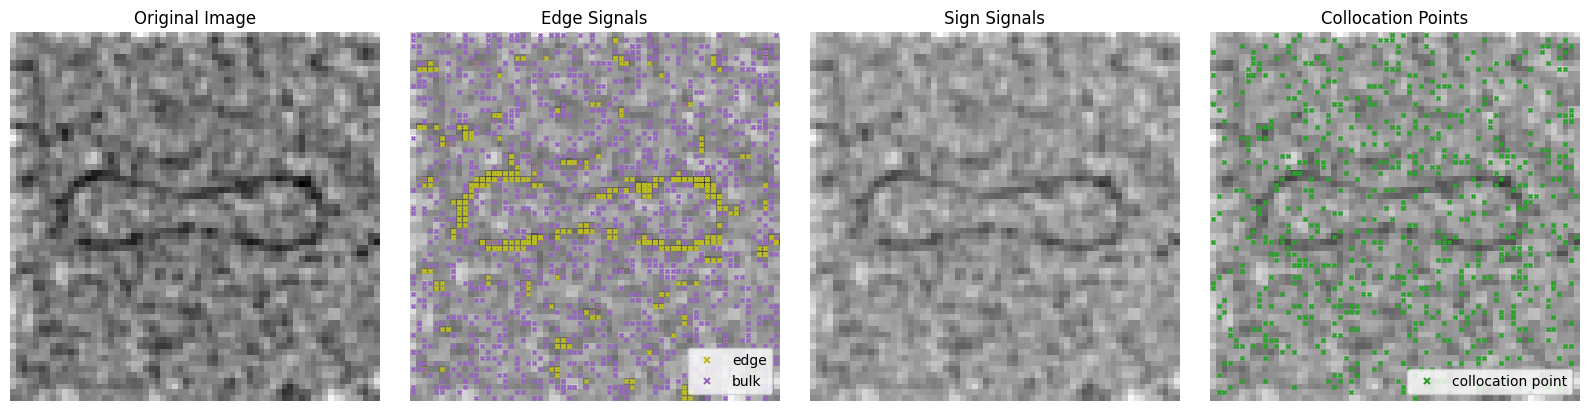

In [23]:
from data_generation.preprocess import plot_sampling_points

axis = "x"
slice_index =32

# tmp = cryoET_data> 0.78

plot_sampling_points(cryoET_data, data_edge, data_sign, data_phys, axis=axis, slice_index=slice_index)
# plot_sampling_points(cryoET_data, data_edge, data_sign, data_curv, axis=axis, slice_index=slice_index)
# plot_sampling_points(tmp, data_edge, data_sign, data_curv, axis=axis, slice_index=slice_index)

### Load Data 

In [44]:
from pinn.utils import load_pts_data
from pinn.cryoet_io import load_mrc_data

shape = "biconcave"
shape = "bud_04"
GRID_SIZE = 64
grid_size = 128
mrc_file_path = f"../data/synthetic/mrc/{shape}_a{str_add}_m{str_miss}.mrc"
cryoET_data = load_mrc_data(mrc_file_path, grid_size=GRID_SIZE)

pts_path = f"../data/synthetic/pts"
data_edge = load_pts_data(f"{pts_path}/edge/e_{shape}_a{str_add}_m{str_miss}_g{grid_size}.npz")
data_sign = load_pts_data(f"{pts_path}/sign/s_{shape}.npz")
# data_sign = load_pts_data(f"{pts_path}/sign/{shape}_manual_signs.npz")
data_phys = load_pts_data(f"{pts_path}/phys/p_{shape}.npz")
# data_curv = load_pts_data(f"{pts_path}/curv/c_{shape}.npz")

### Save Data

In [7]:
from pinn.utils import save_pts_data

save_data_dir = f"../data/synthetic/pts"
# save_pts_data(data_sign, f"{save_data_dir}/sign/s_{shape}.npz", meta_sign)
# save_pts_data(data_phys, f"{save_data_dir}/phys/p_{shape}.npz", meta_phys)
# save_pts_data(data_phys, f"{save_data_dir}/phys/p_{shape}_b3_n80000.npz", meta_phys)
# save_pts_data(data_edge, f"{save_data_dir}/edge/e_{shape}_a{str_add}_m{str_miss}.npz", meta_edge)
# save_pts_data(data_edge, f"{save_data_dir}/edge/e_{shape}_a{str_add}_w00_t60.npz", meta_edge)
# save_pts_data(data_edge, f"{save_data_dir}/edge/e_{shape}_a000_m00.npz", meta_edge)

# save_pts_data(data_curv, f"{save_data_dir}/curv/c_{shape}.npz", meta_curv)
save_pts_data(data_curv, f"{save_data_dir}/curv/dummy.npz", meta_curv)

## manually appending data

In [54]:
import jax.numpy as jnp

new_points = jnp.array([[-0.061887  , -0.026523  ,  0.08661418],
       [ 0.0335958 , -0.0477414 ,  0.08661418],
       [ 0.008841  ,  0.0229866 ,  0.08661418],
       [-0.23517062,  0.00176822,  0.18110237],
       [ 0.15383334, -0.18212464,  0.18110237],
       [ 0.09017824,  0.18212458,  0.18110237],
       [ 0.1467606 , -0.02298659,  0.1496063 ],
       [-0.18212464, -0.04420501,  0.1496063 ],
       [-0.0371322 , -0.17151539,  0.1496063 ],
       [ 0.10432386, -0.0123774 ,  0.13385814],
       [-0.1113966 , -0.0053046 ,  0.13385826],
       [-0.1396878 ,  0.1184694 ,  0.16535433],
       [-0.19273381, -0.0229866 ,  0.16535433],
       [-0.0901782 , -0.1891974 ,  0.16535433],
       [ 0.1078602 , -0.1785882 ,  0.16535433],
       [ 0.1785882 , -0.0654234 ,  0.16535433],
       [ 0.1467606 ,  0.1007874 ,  0.16535433]], dtype=jnp.float32)

new_labels = jnp.array([ 1.,  1.,  1., -1., -1., -1., -1., -1., -1., -1., -1., -1., -1.,
       -1., -1., -1., -1.], dtype=jnp.float32)

# Append
data_sign = {
    "points": jnp.concatenate([data_sign["points"], new_points], axis=0),
    "label":  jnp.concatenate([data_sign["label"],  new_labels], axis=0),
}


In [15]:
from pinn.plot import write_vtk_point_cloud
from pinn.utils import load_pts_data

shape = "biconcave"
additive = 0.00
missing  = 0.0

str_add = f"{additive:.2f}".replace('.', '')
str_miss = f"{missing:.1f}".replace('.', '')

pts_path = f"../data/synthetic/pts_data"
# data_edge = load_pts_data(f"{pts_path}/edge/e_{shape}_a{str_add}_m{str_miss}.npz", perm=(2,1,0))
# data_sign = load_pts_data(f"{pts_path}/sign/s_{shape}.npz", perm=(2,1,0))
data_phys = load_pts_data(f"{pts_path}/phys/p_biconcave_b3_n80000.npz", perm=(2,1,0))

# write_vtk_point_cloud(
#     "pts_data_edge.vtk",
#     data_edge["points"],
#     point_scalars={"label": data_edge["label"]}
# )

# write_vtk_point_cloud(
#     "pts_data_sign.vtk",
#     data_sign["points"],
#     point_scalars={"label": data_sign["label"]}
# )

write_vtk_point_cloud(
    "pts_data_phys_b3_n80000.vtk",
    data_phys["points"]
)

In [45]:
data_sign

{'points': array([[-0.96316457, -0.85926557,  0.86596394],
        [ 0.40689445, -0.16339302, -0.86561584],
        [ 0.6247344 , -0.6730921 , -0.36441207],
        ...,
        [ 0.6365042 , -0.5555506 , -0.9302647 ],
        [ 0.5580821 ,  0.16370487, -0.73220277],
        [-0.5210438 ,  0.37891722,  0.5685582 ]],
       shape=(5000, 3), dtype=float32),
 'label': array([-1.,  1., -1., ...,  1.,  1., -1.], shape=(5000,), dtype=float32),
 'meta': {'type': 'sign',
  'label_meaning': {1: 'postive', -1: 'negative'},
  'n_sample': 5000,
  'threshold': 0.9,
  'phi_fn': '/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/bud_04/data_0321/a000_m00/phase1_100000_1_100000_0/checkpoint_10000'}}